# DiCE imeplementation
letsss gooo

our goal: for employees predict to leave (*Attition =1*) generate counterfactual explanatios that show the minimal changes needed so the model would predict they stay (*Attition =0*).

Our expected output will be 
- counterfactual tables for Random Forest 
- counterfactual tables for XGBoost 
- side-by-side comparison of suggested feature changes per model

# 1.Paths and imports

In [97]:
import os

BASE_PATH = os.path.abspath(os.path.join(os.path.dirname('__file__'), '..'))
DATA      = os.path.join(BASE_PATH, 'data', 'processed')
RF_PATH   = os.path.join(BASE_PATH, 'data', 'models', 'RF')
XGB_PATH  = os.path.join(BASE_PATH, 'data', 'models', 'XGBoost')

print(f'Base:      {BASE_PATH}')
print(f'Processed: {DATA}')
print(f'RF model:  {RF_PATH}')
print(f'XGB model: {XGB_PATH}')

Base:      c:\Users\kamil\Desktop_new\Local\Universidad\H512 Current Trends\infoh512-project
Processed: c:\Users\kamil\Desktop_new\Local\Universidad\H512 Current Trends\infoh512-project\data\processed
RF model:  c:\Users\kamil\Desktop_new\Local\Universidad\H512 Current Trends\infoh512-project\data\models\RF
XGB model: c:\Users\kamil\Desktop_new\Local\Universidad\H512 Current Trends\infoh512-project\data\models\XGBoost


## 2. Libraries

In [98]:
SEED = 48

import pickle
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import dice_ml

warnings.filterwarnings('ignore')
np.random.seed(SEED)

print('Libraries loaded.')
try:
    import importlib.metadata
    print(f'  dice-ml version: {importlib.metadata.version("dice-ml")}')
except Exception:
    print('  dice-ml loaded OK')

Libraries loaded.
  dice-ml version: 0.12


## 3. Load Models, Scalers & Data

In [99]:
def load_pickle(path):
    with open(path, 'rb') as f:
        return pickle.load(f)

# RF artifacts
rf_model      = load_pickle(os.path.join(RF_PATH,  'random_forest.pkl'))
rf_scaler     = load_pickle(os.path.join(RF_PATH,  'scaler.pkl'))
rf_le         = load_pickle(os.path.join(RF_PATH,  'label_encoders.pkl'))
feature_names = load_pickle(os.path.join(RF_PATH,  'feature_names.pkl'))

# XGBoost artifacts
xgb_model  = load_pickle(os.path.join(XGB_PATH, 'xgboost.pkl'))
xgb_scaler = load_pickle(os.path.join(XGB_PATH, 'scaler.pkl'))
xgb_le     = load_pickle(os.path.join(XGB_PATH, 'label_encoders.pkl'))

# Processed arrays
X_train_scaled = np.load(os.path.join(DATA, 'X_train.npy'))
X_test_scaled  = np.load(os.path.join(DATA, 'X_test.npy'))
y_train        = np.load(os.path.join(DATA, 'y_train.npy'))
y_test         = np.load(os.path.join(DATA, 'y_test.npy'))

print('All artifacts loaded.')
print(f'  Features : {len(feature_names)}')
print(f'  X_train  : {X_train_scaled.shape}')
print(f'  X_test   : {X_test_scaled.shape}')

All artifacts loaded.
  Features : 30
  X_train  : (1029, 30)
  X_test   : (221, 30)


## 4. DataFrames 

In [100]:
# Inverse-scale to get original numeric values (categoricals stay as integer codes)
X_train_orig = rf_scaler.inverse_transform(X_train_scaled)
X_test_orig  = rf_scaler.inverse_transform(X_test_scaled)

df_train = pd.DataFrame(X_train_orig, columns=feature_names).round(0).astype(float)
df_test  = pd.DataFrame(X_test_orig,  columns=feature_names).round(0).astype(float)

df_train['Attrition'] = y_train.astype(int)
df_test['Attrition']  = y_test.astype(int)

print(f'Training set : {df_train.shape}  | Attrition rate: {y_train.mean():.1%}')
print(f'Test set     : {df_test.shape}  | Attrition rate: {y_test.mean():.1%}')
df_train.head(3)

Training set : (1029, 31)  | Attrition rate: 16.1%
Test set     : (221, 31)  | Attrition rate: 16.3%


,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,HourlyRate,...,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition
0,19.0,2.0,645.0,1.0,9.0,2.0,1.0,3.0,1.0,54.0,...,3.0,0.0,1.0,4.0,3.0,1.0,1.0,0.0,0.0,0
1,33.0,2.0,1277.0,1.0,15.0,1.0,3.0,2.0,1.0,56.0,...,4.0,0.0,15.0,2.0,4.0,7.0,6.0,7.0,7.0,1
2,52.0,2.0,1325.0,1.0,11.0,4.0,1.0,4.0,0.0,82.0,...,2.0,1.0,9.0,3.0,3.0,5.0,2.0,1.0,4.0,0


# Dice

## 1. Feature Type Configuration

In [101]:
# Categorical / ordinal features (DiCE will only allow valid integer levels)
CATEGORICAL_FEATURES = [
    'BusinessTravel', 'Department', 'EducationField',
    'Gender', 'JobRole', 'MaritalStatus', 'OverTime',
    'Education', 'EnvironmentSatisfaction', 'JobInvolvement',
    'JobLevel', 'JobSatisfaction', 'PerformanceRating',
    'RelationshipSatisfaction', 'StockOptionLevel', 'WorkLifeBalance',
]

# DiCE receives ALL features as continuous (they are already numeric float64)
# This avoids the pandas 2.x LossySetitemError caused by DiCE's internal string conversion
CONTINUOUS_FEATURES = feature_names  # all 30 features

# Inmutble Variables. Things that happend in the past , that are out of HR control, and that we don't want to change for retention purposes.

# Immutable: HR cannot change these for retention purposes
IMMUTABLE_DEMOGRAPHIC = ['Age', 'Gender', 'MaritalStatus', 'EducationField', 'Department']

# Immutable: time-based features HR cannot change in the short term for retention purposes
IMMUTABLE_TIME = [
    'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
    'YearsWithCurrManager', 'TotalWorkingYears', 'NumCompaniesWorked',
]

IMMUTABLE_HISTORICAL  = [
    'PercentSalaryHike', 'PerformanceRating', 'Education',
    'HourlyRate', 'DailyRate', 'MonthlyRate',
]
     # reflect past decisions, not easily changed

IMMUTABLE = IMMUTABLE_DEMOGRAPHIC + IMMUTABLE_TIME + IMMUTABLE_HISTORICAL


# ── Actionable features with realistic bounds ─────────────────────────────────
# Salary: max raise capped at the 75th percentile of the training set (~8,400)
# — a big raise, but still realistic for a retention offer
# JobLevel: at most 1 step up (e.g. 1 → 2, not 1 → 5)
# StockOptions: 0 → 1 or 2 (common grant levels)
PERMITTED_RANGE = {
    'JobLevel':               [1,     3],      # max 2 levels up
    'StockOptionLevel':       [0,     2],      # common grant: 0, 1 or 2
    'WorkLifeBalance':        [1,     4],
    'EnvironmentSatisfaction':[1,     4],
    'JobSatisfaction':        [1,     4],
    'JobInvolvement':         [1,     4],
    'RelationshipSatisfaction':[1,    4],
    'TrainingTimesLastYear':  [0,     6],
}

MAX_SALARY_INCREASE = 0.50  

print('Immutable demograficas :', IMMUTABLE_DEMOGRAPHIC)
print('Immutable temporales   :', IMMUTABLE_TIME)
print('Immutable historicas   :', IMMUTABLE_HISTORICAL)
print()
print('Accionables con bounds :')
for k, v in PERMITTED_RANGE.items():
    print(f'  {k}: {v}')
print(f'  MonthlyIncome: [salario_actual, salario_actual * {1 + MAX_SALARY_INCREASE}]  (dinamico por empleado)')


Immutable demograficas : ['Age', 'Gender', 'MaritalStatus', 'EducationField', 'Department']
Immutable temporales   : ['YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'TotalWorkingYears', 'NumCompaniesWorked']
Immutable historicas   : ['PercentSalaryHike', 'PerformanceRating', 'Education', 'HourlyRate', 'DailyRate', 'MonthlyRate']

Accionables con bounds :
  JobLevel: [1, 3]
  StockOptionLevel: [0, 2]
  WorkLifeBalance: [1, 4]
  EnvironmentSatisfaction: [1, 4]
  JobSatisfaction: [1, 4]
  JobInvolvement: [1, 4]
  RelationshipSatisfaction: [1, 4]
  TrainingTimesLastYear: [0, 6]
  MonthlyIncome: [salario_actual, salario_actual * 1.5]  (dinamico por empleado)


## 2. Model Wrappers for Dice

In [102]:
class ScaledModelWrapper:
    """Wraps a sklearn/XGBoost model + its scaler so DiCE passes unscaled data."""

    def __init__(self, model, scaler, feature_names):
        self.model         = model
        self.scaler        = scaler
        self.feature_names = feature_names

    def predict(self, X):
        if isinstance(X, pd.DataFrame):
            X = X[self.feature_names].values
        return self.model.predict(self.scaler.transform(X))

    def predict_proba(self, X):
        if isinstance(X, pd.DataFrame):
            X = X[self.feature_names].values
        return self.model.predict_proba(self.scaler.transform(X))


rf_wrapper  = ScaledModelWrapper(rf_model,  rf_scaler,  feature_names)
xgb_wrapper = ScaledModelWrapper(xgb_model, xgb_scaler, feature_names)

# Sanity-check accuracy
X_test_df = df_test[feature_names].copy()
rf_acc    = (rf_wrapper.predict(X_test_df)  == y_test).mean()
xgb_acc   = (xgb_wrapper.predict(X_test_df) == y_test).mean()
print(f'RF  accuracy on test set : {rf_acc:.3f}')
print(f'XGB accuracy on test set : {xgb_acc:.3f}')
print('Wrappers working correctly.')

RF  accuracy on test set : 0.855
XGB accuracy on test set : 0.846
Wrappers working correctly.


## 3.Building DiCE data & Model Objects

In [103]:
# Ensure all feature columns are float64 — required for DiCE + pandas 2.x compatibility
for col in feature_names:
    df_train[col] = df_train[col].astype('float64')
    df_test[col]  = df_test[col].astype('float64')

# DiCE Data object — all features treated as continuous
dice_data = dice_ml.Data(
    dataframe           = df_train,
    continuous_features = list(feature_names),
    outcome_name        = 'Attrition'
)

# DiCE Model objects
dice_rf_model  = dice_ml.Model(model=rf_wrapper,  backend='sklearn', model_type='classifier')
dice_xgb_model = dice_ml.Model(model=xgb_wrapper, backend='sklearn', model_type='classifier')

# DiCE Explainers (random method — fast, model-agnostic)
exp_rf  = dice_ml.Dice(dice_data, dice_rf_model,  method='random')
exp_xgb = dice_ml.Dice(dice_data, dice_xgb_model, method='random')

print('DiCE explainers ready.')

DiCE explainers ready.


## 4. Select Query Instances

In [104]:
rf_preds  = rf_wrapper.predict(X_test_df)
xgb_preds = xgb_wrapper.predict(X_test_df)

# Verdaderos positivos de ambos modelos
both_attrition_idx = np.where(
    (rf_preds == 1) & (xgb_preds == 1) & (y_test == 1)
)[0]
print(f'True positives predichos por AMBOS modelos: {len(both_attrition_idx)}')

# Seleccionar 3 instancias
np.random.seed(SEED)
selected_idx    = np.random.choice(both_attrition_idx, size=min(3, len(both_attrition_idx)), replace=False)
query_instances = X_test_df.iloc[selected_idx].reset_index(drop=True).astype('float64')

print(f'Indices seleccionados: {selected_idx}')
query_instances

True positives predichos por AMBOS modelos: 6
Indices seleccionados: [ 26 110 219]


,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,HourlyRate,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,25.0,1.0,599.0,2.0,24.0,1.0,1.0,3.0,1.0,73.0,...,3.0,4.0,0.0,1.0,4.0,3.0,1.0,0.0,1.0,0.0
1,20.0,1.0,871.0,1.0,6.0,3.0,1.0,4.0,0.0,66.0,...,3.0,2.0,0.0,1.0,5.0,3.0,1.0,0.0,1.0,0.0
2,19.0,2.0,419.0,2.0,21.0,3.0,4.0,4.0,1.0,37.0,...,3.0,2.0,0.0,1.0,3.0,4.0,1.0,0.0,0.0,0.0


## 5.Lets make the counterfactuals!! RF

In [105]:
N_CF             = 3
FEATS_TO_VARY    = [f for f in feature_names if f not in IMMUTABLE]

def generate_cfs(explainer, query_instances, n_cf, seed):
    """Genera CFs instancia por instancia con techo salarial dinamico (+50%)."""
    all_cfs = []
    for i in range(len(query_instances)):
        salary_now   = query_instances.iloc[i]['MonthlyIncome']
        salary_ceil  = round(salary_now * (1 + MAX_SALARY_INCREASE))
        permitted    = {**PERMITTED_RANGE,
                        'MonthlyIncome': [salary_now, salary_ceil]}

        cf = explainer.generate_counterfactuals(
            query_instances.iloc[[i]],
            total_CFs        = n_cf,
            desired_class    = 0,
            features_to_vary = FEATS_TO_VARY,
            permitted_range  = permitted,
            random_seed      = seed,
            verbose          = False
        )
        all_cfs.append(cf.cf_examples_list[0].final_cfs_df)
    return all_cfs

cf_rf_list = generate_cfs(exp_rf, query_instances, N_CF, SEED)
print('RF counterfactuals generados.')
for i, df in enumerate(cf_rf_list):
    n = 0 if df is None else len(df)
    sal = query_instances.iloc[i]['MonthlyIncome']
    print(f'  Empleado {i+1}: {n} CFs  |  salario: ${sal:.0f}  |  techo: ${sal*1.5:.0f}')

100%|██████████| 1/1 [00:01<00:00,  1.12s/it]

RF counterfactuals generados.
  Empleado 1: 3 CFs  |  salario: $1118  |  techo: $1677
  Empleado 2: 3 CFs  |  salario: $2926  |  techo: $4389
  Empleado 3: 3 CFs  |  salario: $2121  |  techo: $3182


## 6.Generate Counterfactual - XGBoost

In [106]:
cf_xgb_list = generate_cfs(exp_xgb, query_instances, N_CF, SEED)
print('XGBoost counterfactuals generados.')
for i, df in enumerate(cf_xgb_list):
    n = 0 if df is None else len(df)
    sal = query_instances.iloc[i]['MonthlyIncome']
    print(f'  Empleado {i+1}: {n} CFs  |  salario: ${sal:.0f}  |  techo: ${sal*1.5:.0f}')

100%|██████████| 1/1 [00:00<00:00,  1.75it/s]

XGBoost counterfactuals generados.
  Empleado 1: 3 CFs  |  salario: $1118  |  techo: $1677
  Empleado 2: 3 CFs  |  salario: $2926  |  techo: $4389
  Empleado 3: 3 CFs  |  salario: $2121  |  techo: $3182


## 6. Helper decode cateogrical values back to labels for interpretability

In [107]:
def decode_row(row, le_dict):
    """Convierte integer-encoded categoricals de vuelta a etiquetas legibles."""
    row = row.copy()
    for col, le in le_dict.items():
        if col in row.index:
            try:
                row[col] = le.inverse_transform([int(float(row[col]))])[0]
            except Exception:
                pass
    return row


def decode_row_df(cf_df, le_dict):
    if cf_df is None or cf_df.empty:
        return cf_df
    return cf_df.apply(lambda r: decode_row(r, le_dict), axis=1)


def get_confidence(cf_df, wrapper):
    """% de probabilidad de QUEDARSE (clase 0) para cada CF."""
    if cf_df is None or cf_df.empty:
        return []
    X = cf_df[[f for f in feature_names if f in cf_df.columns]].copy()
    return [round(p[0] * 100, 1) for p in wrapper.predict_proba(X)]


def get_query_risk(q_row, wrapper):
    """% de probabilidad de IRSE del empleado en su estado actual."""
    X = pd.DataFrame([q_row[feature_names]])
    return round(wrapper.predict_proba(X)[0][1] * 100, 1)


rf_cfs       = [decode_row_df(df, rf_le)  for df in cf_rf_list]
xgb_cfs      = [decode_row_df(df, xgb_le) for df in cf_xgb_list]
query_decoded = query_instances.apply(lambda r: decode_row(r, rf_le), axis=1)
print("Decoding y funciones de confianza listos.")

Decoding y funciones de confianza listos.


## 8.Here is the info

In [108]:
def show_cf_table_with_confidence(instance_idx, model_name, q_row, cf_df, cf_raw, wrapper):
    risk_pct = get_query_risk(query_instances.iloc[instance_idx], wrapper)
    print(f"  Riesgo de fuga ({model_name}): {risk_pct}%")

    if cf_df is None or cf_df.empty:
        print(f"  [{model_name}] Sin counterfactuals validos con techo de +50%.")
        return

    confidences = get_confidence(cf_raw, wrapper)
    rows = []
    for cf_num, (_, cf_row) in enumerate(cf_df.iterrows(), 1):
        conf_str = f"{confidences[cf_num-1]:.1f}%" if cf_num <= len(confidences) else "—"
        for feat in feature_names:
            orig = q_row[feat]; new = cf_row[feat]
            try:
                diff = abs(float(str(orig)) - float(str(new)))
                if diff < 0.05:
                    continue
                if feat == "MonthlyIncome":
                    pct = (float(str(new)) - float(str(orig))) / float(str(orig)) * 100
                    rows.append({"CF #": cf_num, "Feature": feat,
                                 "Original": f"${orig:.0f}",
                                 "Counterfactual": f"${float(str(new)):.0f} (+{pct:.0f}%)",
                                 "Confianza retención": conf_str})
                else:
                    rows.append({"CF #": cf_num, "Feature": feat,
                                 "Original": orig, "Counterfactual": new,
                                 "Confianza retención": conf_str})
            except:
                if str(orig) != str(new):
                    rows.append({"CF #": cf_num, "Feature": feat,
                                 "Original": orig, "Counterfactual": new,
                                 "Confianza retención": conf_str})
    if rows:
        print(f"  -- {model_name} --")
        display(pd.DataFrame(rows).set_index(["CF #", "Feature"]))
    print()


for i in range(len(query_instances)):
    q   = query_decoded.iloc[i]
    sal = q["MonthlyIncome"]
    print(f"============================================================")
    print(f"  Empleado {i+1}  |  Salario: ${sal:.0f}  |  Techo: ${sal*1.5:.0f}  |  OverTime: {q['OverTime']}")
    print(f"============================================================")
    show_cf_table_with_confidence(i, "Random Forest", q, rf_cfs[i],  cf_rf_list[i],  rf_wrapper)
    show_cf_table_with_confidence(i, "XGBoost",       q, xgb_cfs[i], cf_xgb_list[i], xgb_wrapper)

  Empleado 1  |  Salario: $1118  |  Techo: $1677  |  OverTime: 1.0
  Riesgo de fuga (Random Forest): 80.0%
  -- Random Forest --


Original  Counterfactual Confianza retención
CF # Feature                                                              
1    BusinessTravel                1.0             0.1               50.0%
     DistanceFromHome             24.0             2.9               50.0%
     JobInvolvement                1.0             1.2               50.0%
     OverTime                      1.0             0.1               50.0%
     StockOptionLevel              0.0             0.1               50.0%
2    BusinessTravel                1.0             0.1               50.0%
     DistanceFromHome             24.0             2.2               50.0%
     JobInvolvement                1.0             1.1               50.0%
     OverTime                      1.0             0.0               50.0%
     StockOptionLevel              0.0             0.1               50.0%
     TrainingTimesLastYear         4.0             0.3               50.0%
3    BusinessTravel                1.0             0.2               53.0%
     DistanceFromHome             24.0             3.3               53.0%
     EnvironmentSatisfaction       3.0             1.3               53.0%
     JobInvolvement                1.0             1.3               53.0%
     JobRole                       8.0             0.7               53.0%
     OverTime                      1.0             0.1               53.0%


  Riesgo de fuga (XGBoost): 100.0%
  -- XGBoost --


Original  Counterfactual Confianza retención
CF # Feature                                                     
1    BusinessTravel       1.0             0.9               55.1%
     OverTime             1.0             0.5               55.1%
2    BusinessTravel       1.0             0.7               55.1%
     OverTime             1.0             0.4               55.1%
3    BusinessTravel       1.0             0.2               55.1%
     OverTime             1.0             0.1               55.1%


  Empleado 2  |  Salario: $2926  |  Techo: $4389  |  OverTime: 1.0
  Riesgo de fuga (Random Forest): 57.5%
  -- Random Forest --


...

Original  Counterfactual Confianza retención
CF # Feature                                                       
1    JobLevel               1.0             2.5               56.1%
     StockOptionLevel       0.0             1.5               56.1%
2    JobInvolvement         2.0             2.6               81.7%
     OverTime               1.0             0.6               81.7%
3    JobInvolvement         2.0             3.3               51.9%
     JobRole                2.0             5.9               51.9%


  Empleado 3  |  Salario: $2121  |  Techo: $3182  |  OverTime: 1.0
  Riesgo de fuga (Random Forest): 94.0%
  -- Random Forest --


Original Counterfactual Confianza retención
CF # Feature                                                             
1    JobLevel                      1.0            2.9               52.0%
     MonthlyIncome               $2121   $3096 (+46%)               52.0%
     StockOptionLevel              0.0            1.9               52.0%
     TrainingTimesLastYear         3.0            5.6               52.0%
2    JobLevel                      1.0            2.6               53.5%
     JobRole                       8.0            6.2               53.5%
     MonthlyIncome               $2121   $2937 (+38%)               53.5%
     StockOptionLevel              0.0            1.6               53.5%
     TrainingTimesLastYear         3.0            4.7               53.5%
3    JobLevel                      1.0            2.9               52.5%
     MonthlyIncome               $2121   $3087 (+46%)               52.5%
     RelationshipSatisfaction      2.0            3.8               52.5%
     StockOptionLevel              0.0            1.9               52.5%


  Riesgo de fuga (XGBoost): 100.0%
  -- XGBoost --


Original Counterfactual Confianza retención
CF # Feature                                                             
1    JobInvolvement                2.0            4.0               55.1%
     MonthlyIncome               $2121   $3150 (+49%)               55.1%
     RelationshipSatisfaction      2.0            4.0               55.1%
     StockOptionLevel              0.0            2.0               55.1%
2    JobRole                       8.0            5.2               61.7%
     JobSatisfaction               2.0            3.0               61.7%
     MonthlyIncome               $2121   $2801 (+32%)               61.7%
     OverTime                      1.0            0.7               61.7%
3    JobRole                       8.0            6.8               58.2%
     MonthlyIncome               $2121   $3010 (+42%)               58.2%
     OverTime                      1.0            0.9               58.2%
     WorkLifeBalance               4.0            3.6               58.2%

## 9. Visualization

  Empleado 1  |  Salario: USD 1118  |  Techo +50%%: USD 1677  |  OverTime: 1.0


,Valor original,RF sugiere,XGBoost sugiere
Feature,,,
BusinessTravel,Travel_Frequently,Non-Travel,Non-Travel
DistanceFromHome,24,2.9 / 2.2 / 3.3,—
EnvironmentSatisfaction,3,1.3,—
JobRole,Sales Representative,Human Resources,—
OverTime,Yes,No,No
TrainingTimesLastYear,4,0.3,—


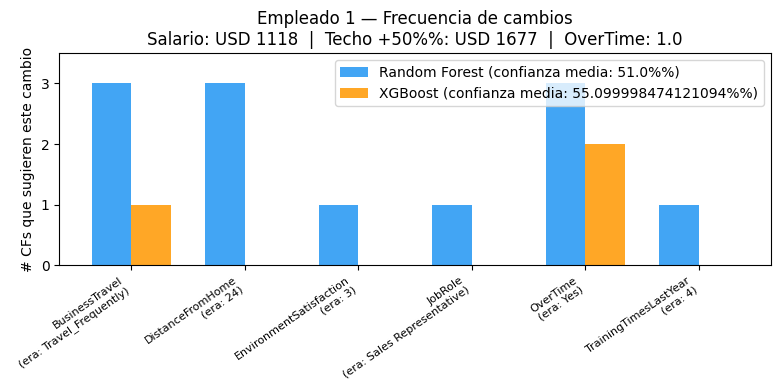

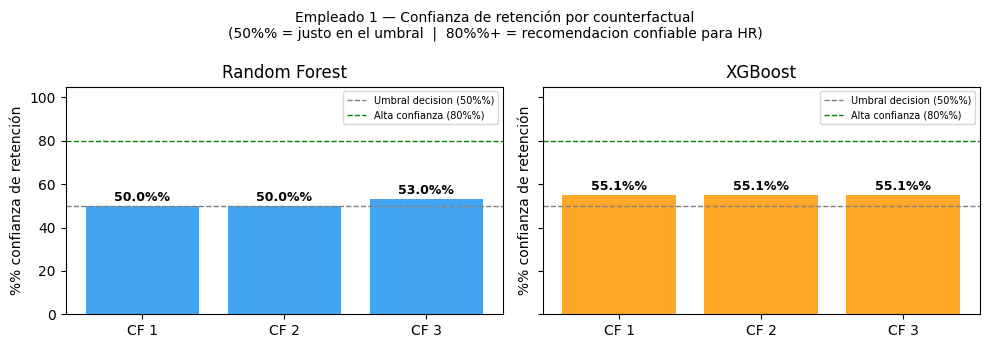

  Empleado 2  |  Salario: USD 2926  |  Techo +50%%: USD 4389  |  OverTime: 1.0


,Valor original,RF sugiere,XGBoost sugiere
Feature,,,
DistanceFromHome,6,12.6,—
EnvironmentSatisfaction,4,2.1,—
JobInvolvement,2,—,2.6 / 3.3
JobLevel,1,—,2.5
JobRole,Laboratory Technician,—,Research Scientist
OverTime,Yes,No,—
StockOptionLevel,0,0.9 / 1.6,1.5


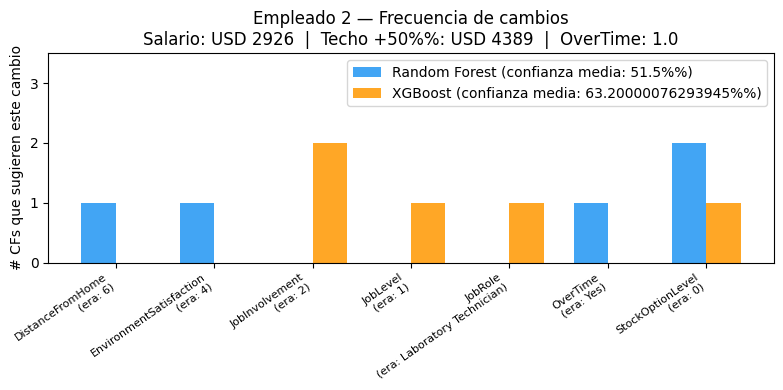

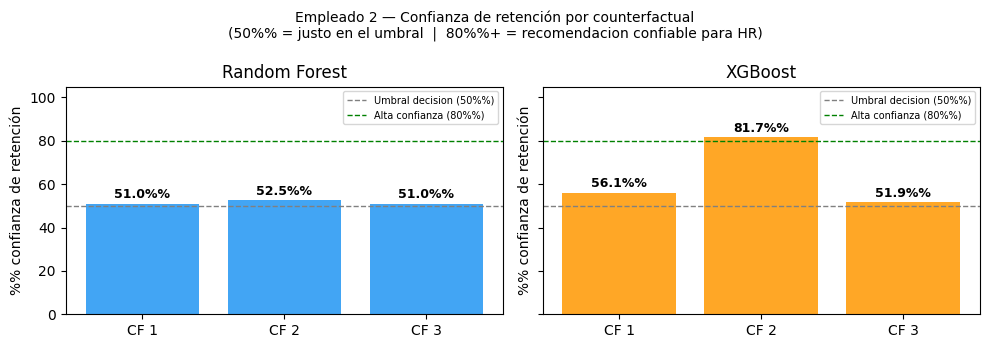

  Empleado 3  |  Salario: USD 2121  |  Techo +50%%: USD 3182  |  OverTime: 1.0


,Valor original,RF sugiere,XGBoost sugiere
Feature,,,
JobInvolvement,2,—,4
JobLevel,1,2.9 / 2.6,—
JobRole,Sales Representative,Research Scientist,Research Director / Sales Executive
JobSatisfaction,2,—,3
MonthlyIncome,USD 2121,USD 2937–3096 (+38%% a +46%%),USD 2801–3150 (+32%% a +49%%)
RelationshipSatisfaction,2,3.8,4
StockOptionLevel,0,1.9 / 1.6,2
TrainingTimesLastYear,3,5.6 / 4.7,—


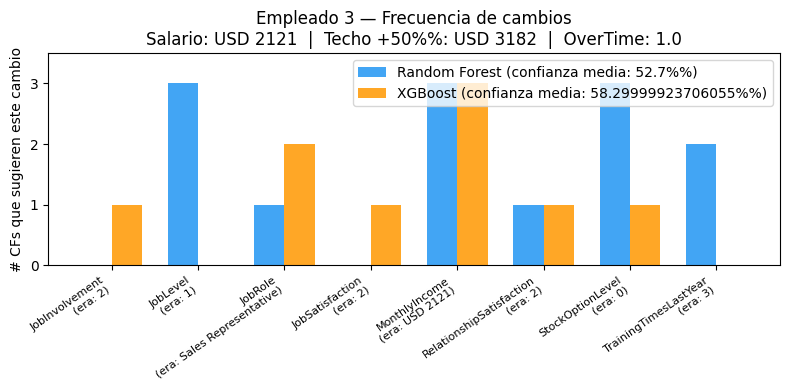

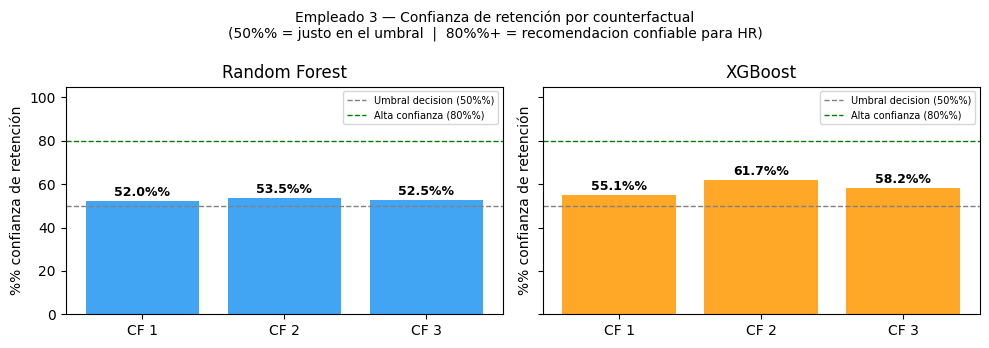

In [109]:
def get_change_freq(q_row, cf_df):
    if cf_df is None or cf_df.empty:
        return pd.Series(dtype=int)
    counter = {}
    for _, cf_row in cf_df.iterrows():
        for feat in feature_names:
            orig = q_row[feat]; new = cf_row[feat]
            try:
                if abs(float(str(orig)) - float(str(new))) > 0.5:   # threshold mayor para categoricos
                    counter[feat] = counter.get(feat, 0) + 1
            except:
                if str(orig) != str(new):
                    counter[feat] = counter.get(feat, 0) + 1
    return pd.Series(counter)


def fmt_value(val, feat, le_dict):
    """Formatea un valor: decodifica categoricos, redondea numericos."""
    if feat in le_dict:
        try:
            return le_dict[feat].inverse_transform([int(round(float(str(val))))])[0]
        except:
            return str(val)
    try:
        f = float(str(val))
        if feat == "MonthlyIncome":
            return f"USD {f:.0f}"
        if f == int(f):
            return int(f)
        return round(f, 1)
    except:
        return str(val)


def get_cf_suggestions(feat, q_row, cf_df, le_dict):
    """Valores sugeridos por DiCE para un feature, decodificados y redondeados."""
    if cf_df is None or cf_df.empty:
        return []
    vals = []
    for _, cf_row in cf_df.iterrows():
        orig = q_row[feat]; new = cf_row[feat]
        try:
            if abs(float(str(orig)) - float(str(new))) > 0.5:
                vals.append(fmt_value(new, feat, le_dict))
        except:
            if str(orig) != str(new):
                vals.append(fmt_value(new, feat, le_dict))
    return vals


def fmt_suggestion(vals, feat, orig_val):
    """Formatea la columna de sugerencias para la tabla resumen."""
    if not vals:
        return "—"
    unique = list(dict.fromkeys([str(v) for v in vals]))
    if feat == "MonthlyIncome":
        try:
            floats = [float(str(v).replace("USD ", "")) for v in vals]
            orig_f = float(str(orig_val))
            mn, mx = min(floats), max(floats)
            pct_mn = (mn - orig_f) / orig_f * 100
            pct_mx = (mx - orig_f) / orig_f * 100
            if abs(mn - mx) < 1:
                return f"USD {mn:.0f} (+{pct_mn:.0f}%%)"
            return f"USD {mn:.0f}–{mx:.0f} (+{pct_mn:.0f}%% a +{pct_mx:.0f}%%)"
        except:
            pass
    if len(unique) == 1:
        return unique[0]
    return " / ".join(unique)


for i in range(len(query_instances)):
    q        = query_decoded.iloc[i]
    rf_freq  = get_change_freq(q, rf_cfs[i])
    xgb_freq = get_change_freq(q, xgb_cfs[i])

    all_feats = sorted(set(rf_freq.index.tolist() + xgb_freq.index.tolist()))
    if not all_feats:
        print(f"Empleado {i+1}: sin cambios detectados.")
        continue

    sal      = q["MonthlyIncome"]
    overtime = q["OverTime"]

    # ── Tabla de valores originales + sugerencias ─────────────────────────
    summary_rows = []
    for feat in all_feats:
        orig_val     = q[feat]
        orig_display = fmt_value(orig_val, feat, rf_le)
        rf_vals      = get_cf_suggestions(feat, q, rf_cfs[i],  rf_le)
        xgb_vals     = get_cf_suggestions(feat, q, xgb_cfs[i], xgb_le)
        summary_rows.append({
            "Feature":         feat,
            "Valor original":  orig_display,
            "RF sugiere":      fmt_suggestion(rf_vals,  feat, orig_val),
            "XGBoost sugiere": fmt_suggestion(xgb_vals, feat, orig_val),
        })

    print(f"============================================================")
    print(f"  Empleado {i+1}  |  Salario: USD {sal:.0f}  |  Techo +50%%: USD {sal*1.5:.0f}  |  OverTime: {overtime}")
    print(f"============================================================")
    display(pd.DataFrame(summary_rows).set_index("Feature"))

    # ── Grafico 1: frecuencia de cambios ──────────────────────────────────
    rf_conf  = get_confidence(cf_rf_list[i],  rf_wrapper)
    xgb_conf = get_confidence(cf_xgb_list[i], xgb_wrapper)
    rf_mean  = round(np.mean(rf_conf),  1) if rf_conf  else 0
    xgb_mean = round(np.mean(xgb_conf), 1) if xgb_conf else 0

    rf_v  = [rf_freq.get(f, 0)  for f in all_feats]
    xgb_v = [xgb_freq.get(f, 0) for f in all_feats]
    x     = np.arange(len(all_feats))
    width = 0.35

    fig, ax = plt.subplots(figsize=(max(8, len(all_feats)), 4))
    ax.bar(x - width/2, rf_v,  width,
           label=f"Random Forest (confianza media: {rf_mean}%%)", color="#2196F3", alpha=0.85)
    ax.bar(x + width/2, xgb_v, width,
           label=f"XGBoost (confianza media: {xgb_mean}%%)",      color="#FF9800", alpha=0.85)

    # Anotar valor original decodificado bajo cada feature
    orig_labels = [f"{f}\n(era: {fmt_value(q[f], f, rf_le)})" for f in all_feats]
    ax.set_xticks(x)
    ax.set_xticklabels(orig_labels, rotation=35, ha="right", fontsize=8)
    ax.set_ylabel("# CFs que sugieren este cambio")
    ax.set_title(
        f"Empleado {i+1} — Frecuencia de cambios\n"
        f"Salario: USD {sal:.0f}  |  Techo +50%%: USD {sal*1.5:.0f}  |  OverTime: {overtime}"
    )
    ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))
    ax.set_ylim(0, N_CF + 0.5)
    ax.legend()
    plt.tight_layout()
    plt.show()

    # ── Grafico 2: confianza de retención por CF ──────────────────────────
    fig2, axes = plt.subplots(1, 2, figsize=(10, 3.5), sharey=True)
    for ax2, confs, name, color in zip(
        axes,
        [rf_conf, xgb_conf],
        ["Random Forest", "XGBoost"],
        ["#2196F3", "#FF9800"]
    ):
        if not confs:
            ax2.set_title(f"{name}\nSin CFs")
            continue
        bars = ax2.bar([f"CF {j+1}" for j in range(len(confs))], confs, color=color, alpha=0.85)
        ax2.axhline(50, color="gray",  linestyle="--", linewidth=1, label="Umbral decision (50%%)")
        ax2.axhline(80, color="green", linestyle="--", linewidth=1, label="Alta confianza (80%%)")
        ax2.set_ylim(0, 105)
        ax2.set_ylabel("%% confianza de retención")
        ax2.set_title(name)
        ax2.legend(fontsize=7)
        for bar, val in zip(bars, confs):
            ax2.text(bar.get_x() + bar.get_width()/2, val + 1,
                     f"{val:.1f}%%", ha="center", va="bottom", fontsize=9, fontweight="bold")
    fig2.suptitle(
        f"Empleado {i+1} — Confianza de retención por counterfactual\n"
        f"(50%% = justo en el umbral  |  80%%+ = recomendacion confiable para HR)",
        fontsize=10
    )
    plt.tight_layout()
    plt.show()

## 10. Aggregate Analysis

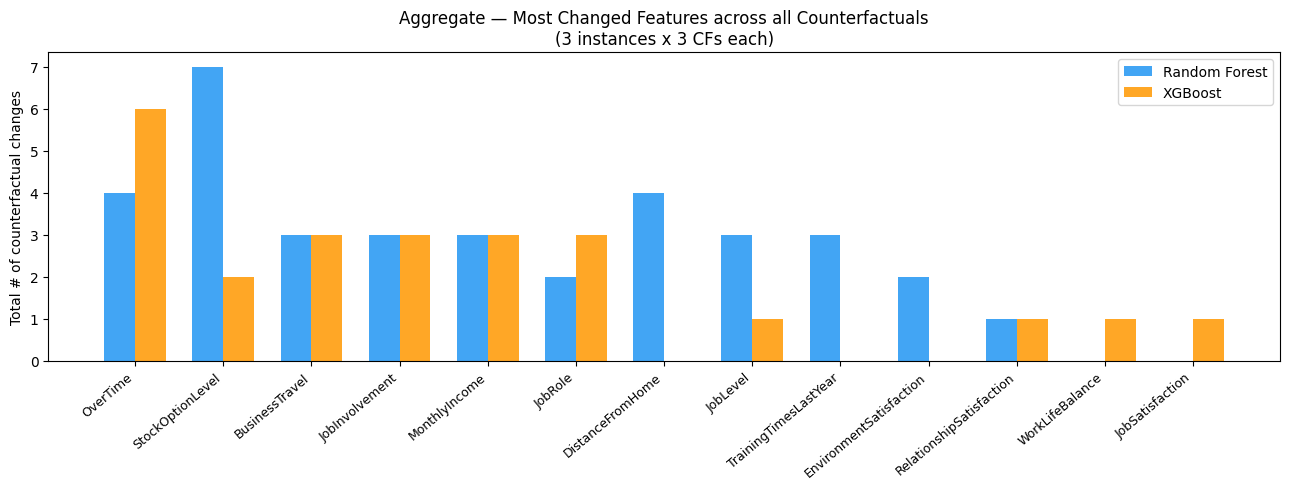

Top 5 by model:
  Random Forest : {'StockOptionLevel': 7, 'OverTime': 4, 'DistanceFromHome': 4, 'JobInvolvement': 3, 'BusinessTravel': 3}
  XGBoost       : {'OverTime': 6, 'BusinessTravel': 3, 'JobRole': 3, 'JobInvolvement': 3, 'MonthlyIncome': 3}


In [110]:
def aggregate_freq(cf_list, q_decoded, n):
    counter = {}
    for i in range(n):
        cf_df = cf_list[i]
        if cf_df is None or cf_df.empty:
            continue
        q_row = q_decoded.iloc[i]
        for _, cf_row in cf_df.iterrows():
            for feat in feature_names:
                if str(q_row[feat]) != str(cf_row[feat]):
                    counter[feat] = counter.get(feat, 0) + 1
    return pd.Series(counter).sort_values(ascending=False)


rf_agg  = aggregate_freq(rf_cfs,  query_decoded, len(query_instances))
xgb_agg = aggregate_freq(xgb_cfs, query_decoded, len(query_instances))

all_feats = sorted(set(rf_agg.index.tolist() + xgb_agg.index.tolist()))
rf_v      = [rf_agg.get(f,  0) for f in all_feats]
xgb_v     = [xgb_agg.get(f, 0) for f in all_feats]
total_v   = [r + x for r, x in zip(rf_v, xgb_v)]

order   = np.argsort(total_v)[::-1]
feats_s = [all_feats[o] for o in order]
rf_s    = [rf_v[o]  for o in order]
xgb_s   = [xgb_v[o] for o in order]

x     = np.arange(len(feats_s))
width = 0.35
fig, ax = plt.subplots(figsize=(max(10, len(feats_s)), 5))
ax.bar(x - width/2, rf_s,  width, label='Random Forest', color='#2196F3', alpha=0.85)
ax.bar(x + width/2, xgb_s, width, label='XGBoost',       color='#FF9800', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(feats_s, rotation=40, ha='right', fontsize=9)
ax.set_ylabel('Total # of counterfactual changes')
ax.set_title(
    f'Aggregate — Most Changed Features across all Counterfactuals\n'
    f'({len(query_instances)} instances x {N_CF} CFs each)'
)
ax.legend()
plt.tight_layout()
plt.show()

print('Top 5 by model:')
print('  Random Forest :', rf_agg.head(5).to_dict())
print('  XGBoost       :', xgb_agg.head(5).to_dict())

## Tips

Mean normalised L1 (lower = closer to retention boundary):


,RF L1,XGBoost L1
Instance,,
Employee 1 (row 26),2.9113,0.8667
Employee 2 (row 110),0.7675,0.7986
Employee 3 (row 219),1.6123,1.1679


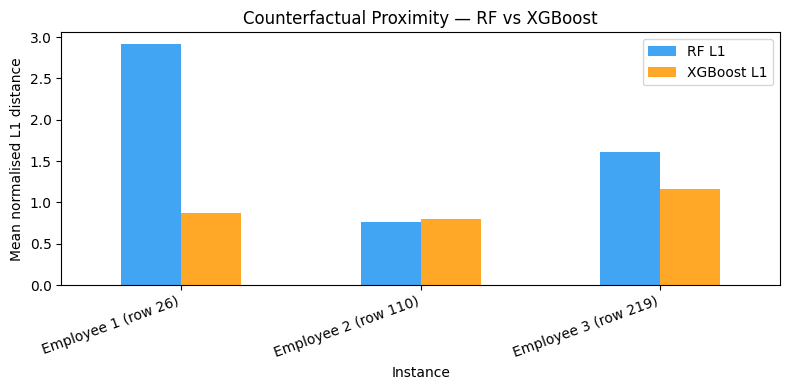

In [111]:
feat_range = (df_train[feature_names].max() - df_train[feature_names].min()).replace(0, 1)


def mean_l1(q_row, cf_df, feat_range):
    if cf_df is None or cf_df.empty:
        return float('nan')
    dists = []
    for _, cf_row in cf_df.iterrows():
        d = sum(
            abs(float(q_row[f]) - float(cf_row[f])) / feat_range[f]
            if str(q_row[f]) != str(cf_row[f]) else 0
            for f in feature_names
        )
        dists.append(d)
    return sum(dists) / len(dists)


records = [
    {
        'Instance':   f'Employee {i+1} (row {selected_idx[i]})',
        'RF L1':      round(mean_l1(query_decoded.iloc[i], rf_cfs[i],  feat_range), 4),
        'XGBoost L1': round(mean_l1(query_decoded.iloc[i], xgb_cfs[i], feat_range), 4),
    }
    for i in range(len(query_instances))
]

dist_df = pd.DataFrame(records).set_index('Instance')
print('Mean normalised L1 (lower = closer to retention boundary):')
display(dist_df)

ax = dist_df.plot(kind='bar', figsize=(8, 4), color=['#2196F3', '#FF9800'], alpha=0.85)
ax.set_ylabel('Mean normalised L1 distance')
ax.set_title('Counterfactual Proximity — RF vs XGBoost')
ax.set_xticklabels(dist_df.index, rotation=20, ha='right')
plt.tight_layout()
plt.show()